In [2]:
!pip install gdown
import gdown
import pandas as pd

url = "https://drive.google.com/file/d/13SXMNuaNrJznox9WanKkgPjRObSX6I8M/view"
gdown.download(url, "data.csv", fuzzy=True)
df = pd.read_csv("data.csv")

Downloading...
From (original): https://drive.google.com/uc?id=13SXMNuaNrJznox9WanKkgPjRObSX6I8M
From (redirected): https://drive.google.com/uc?id=13SXMNuaNrJznox9WanKkgPjRObSX6I8M&confirm=t&uuid=98060c17-ac48-426e-a765-bbe248f9d8a0
To: /content/data.csv
100%|██████████| 171M/171M [00:02<00:00, 61.4MB/s]


### Inspecting Data Shape and Information

This step involves checking the number of rows and columns (`df.shape`) and getting a concise summary of the DataFrame (`df.info()`). This helps us quickly understand the dataset's dimensions, column names, non-null counts, and data types. Look for any unexpected column names, initial data type inconsistencies, or columns with many missing values.

In [3]:
print(f"DataFrame shape: {df.shape}")
display(df.info())

DataFrame shape: (500000, 26)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 26 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   User ID            500000 non-null  object 
 1   User Name          500000 non-null  object 
 2   Driver Name        500000 non-null  object 
 3   Car Condition      500000 non-null  object 
 4   Weather            500000 non-null  object 
 5   Traffic Condition  500000 non-null  object 
 6   key                500000 non-null  object 
 7   fare_amount        500000 non-null  float64
 8   pickup_datetime    500000 non-null  object 
 9   pickup_longitude   500000 non-null  float64
 10  pickup_latitude    500000 non-null  float64
 11  dropoff_longitude  499995 non-null  float64
 12  dropoff_latitude   499995 non-null  float64
 13  passenger_count    500000 non-null  int64  
 14  hour               500000 non-null  int64  
 15  day                50

None

### Interpretation of Data Shape and Information

The dataset has 500,000 rows and 26 columns. Most columns are `object` type, with some `float64` and `int64`. `pickup_datetime` is an `object` type and will require conversion to `datetime` for time-series analysis. Data cleaning and type conversion will be necessary, especially for categorical features currently stored as objects.

### Checking for Missing Values

Before diving deeper, it's crucial to identify if there are any missing values in our dataset. This step counts the number of `NaN` values for each column. High counts of missing values might indicate issues with data collection or require specific handling strategies like imputation or removal.

In [4]:
missing_values = df.isnull().sum()
print("Missing values per column:")
display(missing_values[missing_values > 0])

Missing values per column:


,0
dropoff_longitude,5
dropoff_latitude,5
jfk_dist,5
ewr_dist,5
lga_dist,5
sol_dist,5
nyc_dist,5
distance,5
bearing,5


### Interpretation of Missing Values

Nine numerical columns (`dropoff_longitude`, `dropoff_latitude`, `jfk_dist`, `ewr_dist`, `lga_dist`, `sol_dist`, `nyc_dist`, `distance`, `bearing`) each have 5 missing values. This is a negligible fraction (0.001%) of the dataset, implying minimal impact. These are numerical columns related to location or distance calculations.

### Checking for Duplicate Rows

Identifying and handling duplicate rows is an important step in data cleaning. Duplicate entries can skew analyses and models. This step counts the total number of exact duplicate rows in the DataFrame. If duplicates exist, we'll note their count.

In [5]:
duplicate_rows = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_rows}")

Number of duplicate rows: 0


### Interpretation of Missing Values

Nine numerical columns (`dropoff_longitude`, `dropoff_latitude`, `jfk_dist`, `ewr_dist`, `lga_dist`, `sol_dist`, `nyc_dist`, `distance`, `bearing`) each have 5 missing values. This is a negligible fraction (0.001%) of the dataset, implying minimal impact. These are numerical columns related to location or distance calculations.

### Checking for Duplicate Rows

Identifying and handling duplicate rows is an important step in data cleaning. Duplicate entries can skew analyses and models. This step counts the total number of exact duplicate rows in the DataFrame. If duplicates exist, we'll note their count.

In [6]:
duplicate_rows = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_rows}")

Number of duplicate rows: 0


### Interpretation of Duplicate Rows

No exact duplicate rows were found in the dataset, simplifying the data cleaning process.

### Checking for Constant Columns

Constant columns are those where all values are the same. Such columns provide no variance and therefore no predictive power for machine learning models. This step identifies and lists any columns that have only one unique value.

In [7]:
constant_columns = [col for col in df.columns if df[col].nunique() == 1]
if len(constant_columns) > 0:
    print(f"Constant columns: {constant_columns}")
else:
    print("No constant columns found.")

No constant columns found.


### Interpretation of Constant Columns

No constant columns (columns with only one unique value) were found. All columns potentially contribute to the analysis.

### Checking for Inconsistent Data Types

This step involves a more detailed inspection of each column's data type, especially focusing on 'object' type columns that might contain mixed data types (e.g., numbers and strings) or need to be converted to more appropriate types (like datetime for 'pickup_datetime'). This check helps ensure data integrity and prepares the data for proper analysis and modeling.

In [8]:
for col in df.select_dtypes(include='object').columns:
    print(f"Column '{col}':")
    display(df[col].apply(type).value_counts())


Column 'User ID':


,count
User ID,
<class 'str'>,500000


Column 'User Name':


,count
User Name,
<class 'str'>,500000


Column 'Driver Name':


...

,count
Traffic Condition,
<class 'str'>,500000


Column 'key':


,count
key,
<class 'str'>,500000


Column 'pickup_datetime':


,count
pickup_datetime,
<class 'str'>,500000


### Interpretation of Inconsistent Data Types

Most 'object' columns consistently contain `str` type values. The `pickup_datetime` column is confirmed to be solely `str` type, requiring conversion to a `datetime` object for time-series analysis.

### Univariate Analysis: Numeric Features

For numeric features, we'll examine their distributions using histograms, box plots, and descriptive statistics (mean, median, standard deviation, skewness, kurtosis). This helps us understand the central tendency, spread, shape, and potential outliers in these variables. We will iterate through numeric columns and generate these plots.

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns

for col in numeric_cols:
    print(f"\n--- Analysis for '{col}' ---")
    print("Descriptive Statistics:")
    display(df[col].describe())
    print(f"Skewness: {df[col].skew():.2f}")
    print(f"Kurtosis: {df[col].kurt():.2f}")


--- Analysis for 'fare_amount' ---
Descriptive Statistics:


,fare_amount
count,500000.000000
mean,11.358361
std,9.916617
min,-44.900000
25%,6.000000
50%,8.500000
75%,12.500000
max,500.000000


Skewness: 4.90
Kurtosis: 83.17

--- Analysis for 'pickup_longitude' ---
Descriptive Statistics:


,pickup_longitude
count,500000.000000
mean,-1.265712
std,0.206941
min,-52.119764
25%,-1.291405
50%,-1.291226
75%,-1.290970
max,37.360538


Skewness: -14.01
Kurtosis: 9867.57

--- Analysis for 'pickup_latitude' ---
Descriptive Statistics:


...

Skewness: 7.17
Kurtosis: 51.67

--- Analysis for 'distance' ---
Descriptive Statistics:


,distance
count,499995.000000
mean,19.468775
std,367.299601
min,0.000000
25%,1.214550
50%,2.116970
75%,3.890070
max,12399.956433


Skewness: 22.99
Kurtosis: 531.25

--- Analysis for 'bearing' ---
Descriptive Statistics:


,bearing
count,499995.000000
mean,0.297145
std,1.804548
min,-3.141593
25%,-0.854721
50%,-0.050442
75%,2.206769
max,3.141593


Skewness: -0.02
Kurtosis: -1.11


### Univariate Analysis: Numeric Features - Histograms (Selected Columns)
We'll visualize the distribution of each selected numeric feature using histograms.
Generating histogram for: fare_amount


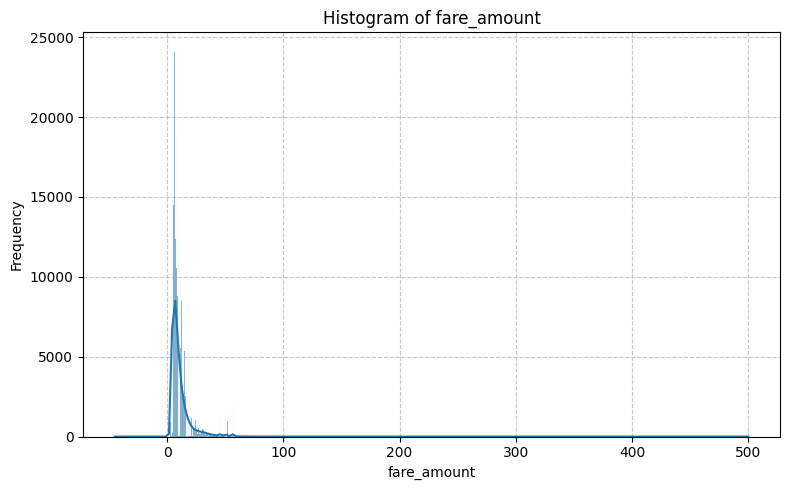

Generating histogram for: passenger_count


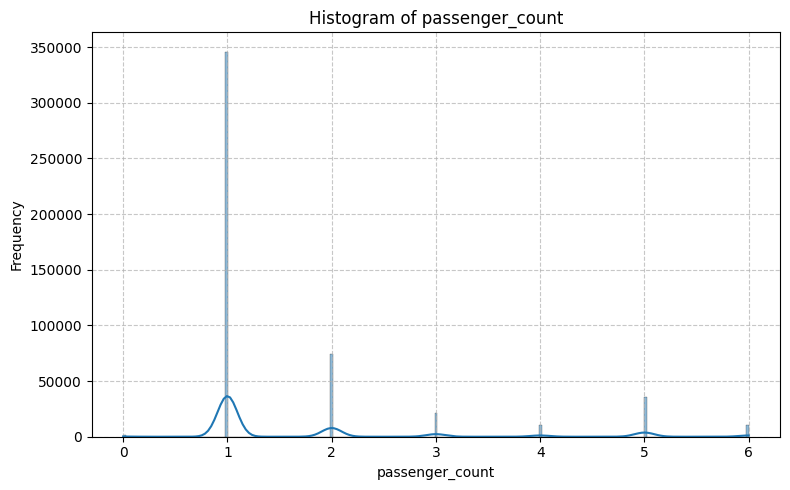

Generating histogram for: distance


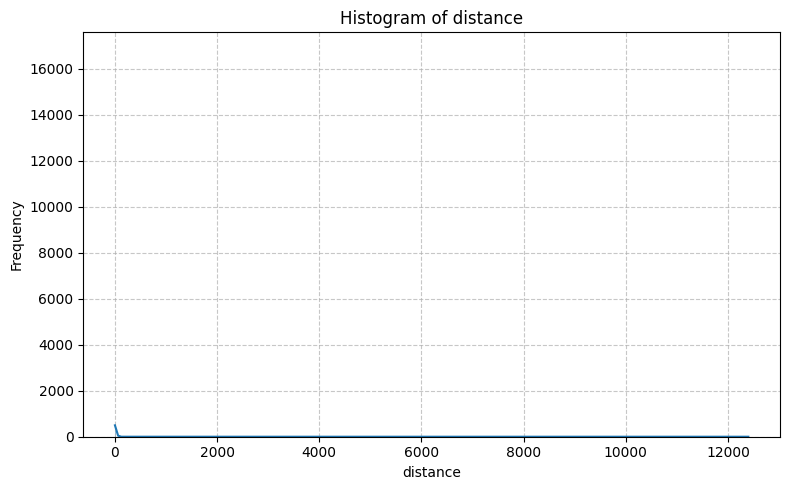

Generating histogram for: hour


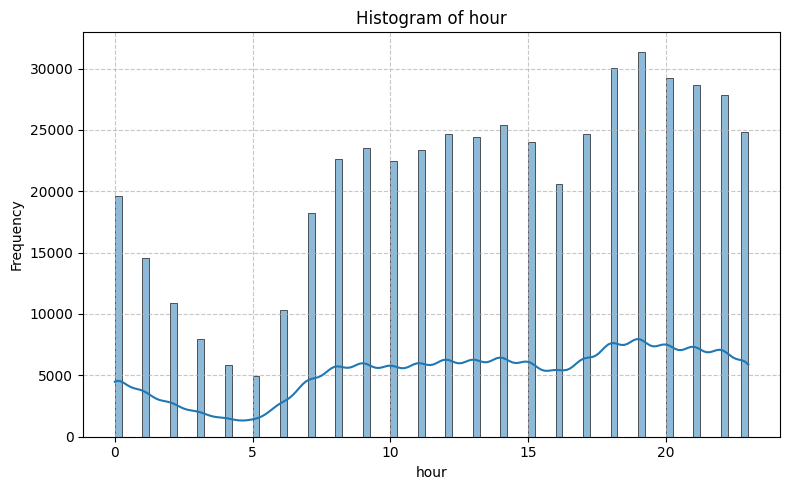

Generating histogram for: day


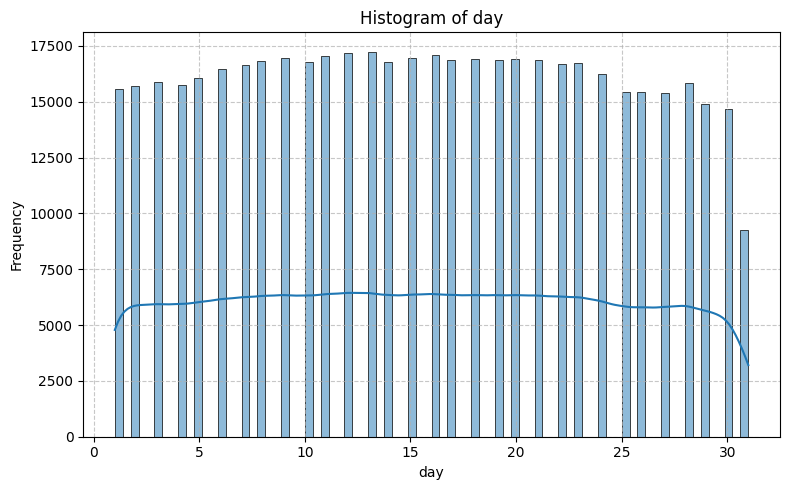

Generating histogram for: month


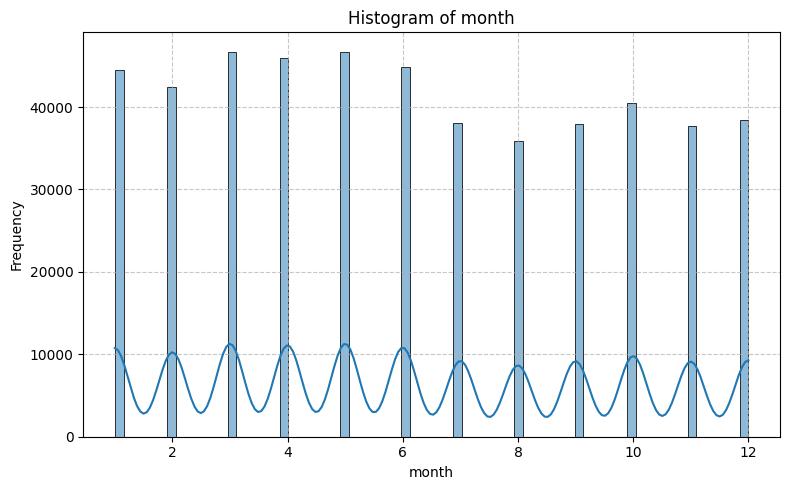

Generating histogram for: weekday


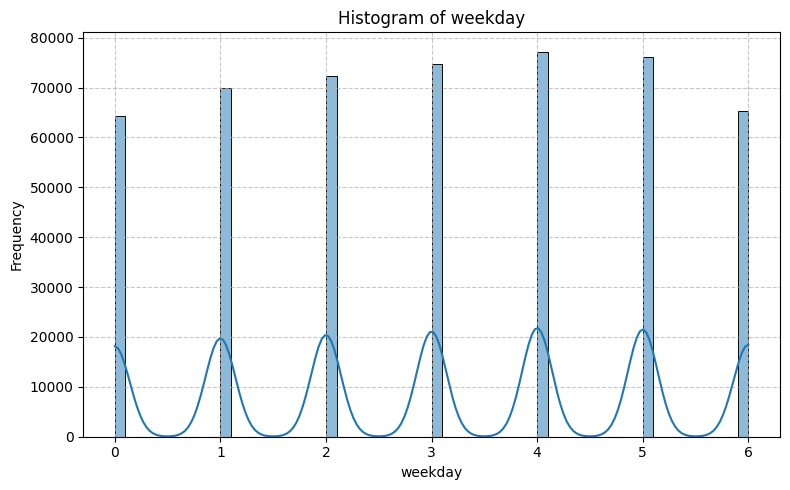

Generating histogram for: year


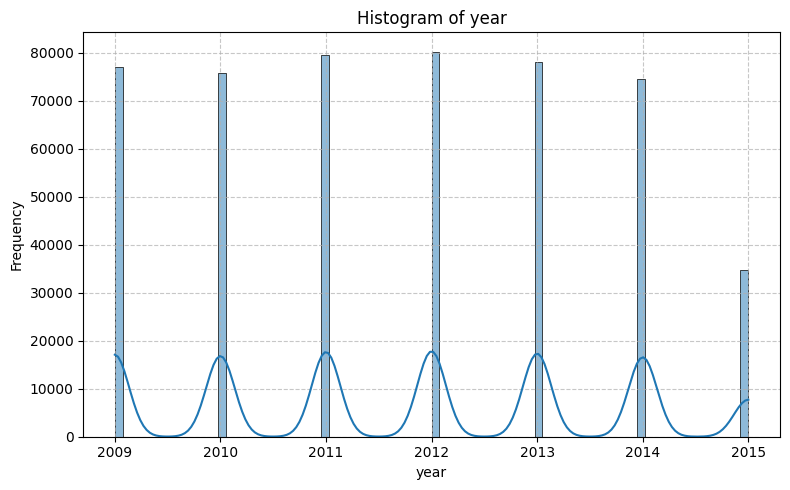

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

numeric_cols = ['fare_amount', 'passenger_count', 'distance', 'hour', 'day', 'month', 'weekday', 'year']

print("distribution of each selected numeric feature using histograms.")

for col in numeric_cols:
    print(f"Generating histogram for: {col}")
    plt.figure(figsize=(8, 5))
    sns.histplot(df[col], kde=True)
    plt.title(f'Histogram of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

### Univariate Analysis: Numeric Features - Box Plots (Selected Columns)
We'll visualize the distribution and potential outliers of each selected numeric feature using box plots.
Generating box plot for: fare_amount


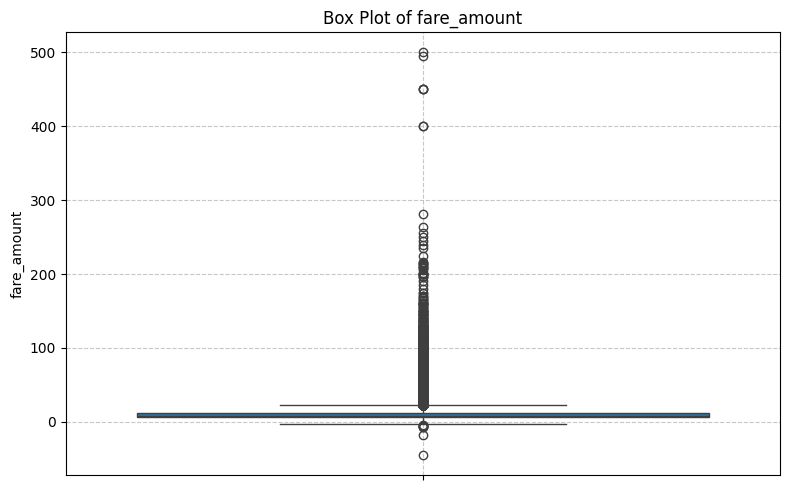

Generating box plot for: passenger_count


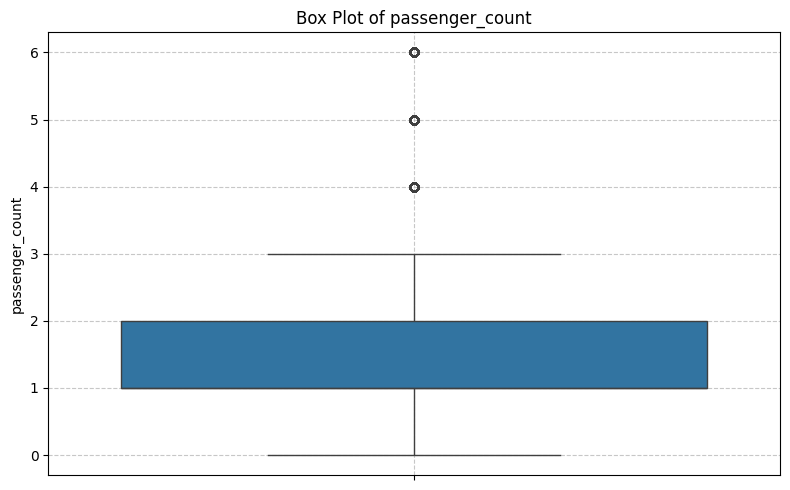

Generating box plot for: distance


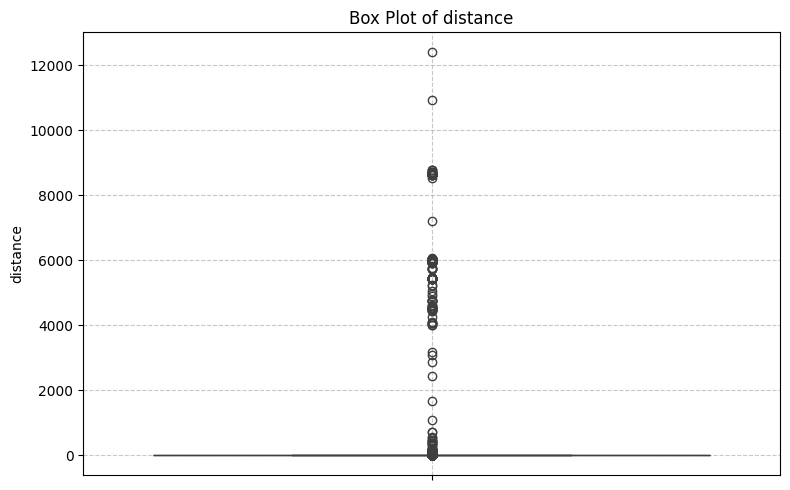

Generating box plot for: hour


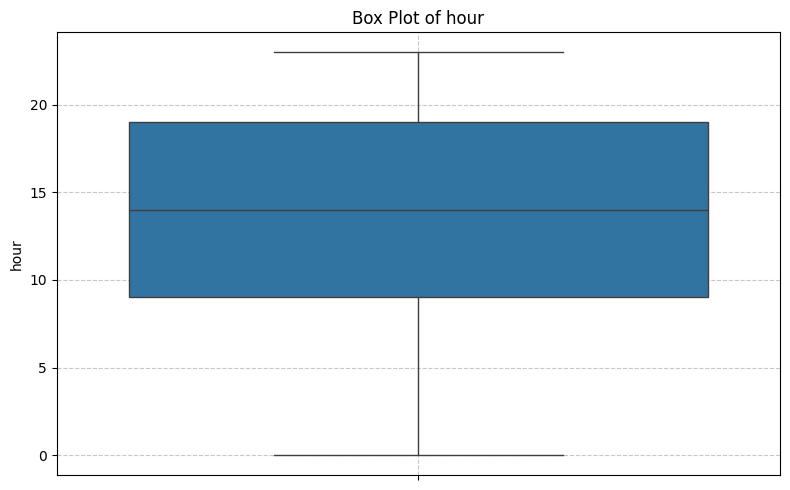

Generating box plot for: day


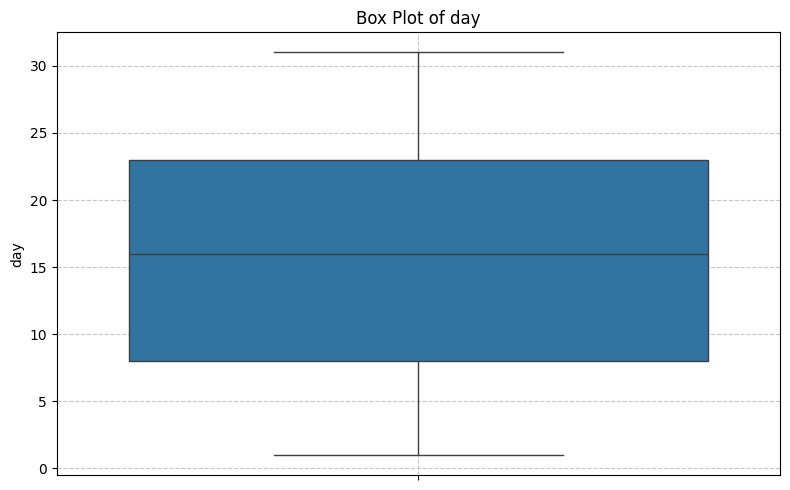

Generating box plot for: month


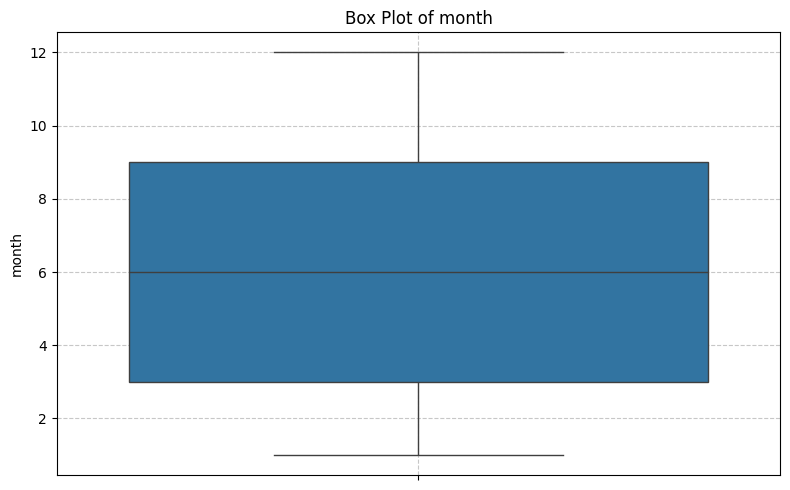

Generating box plot for: weekday


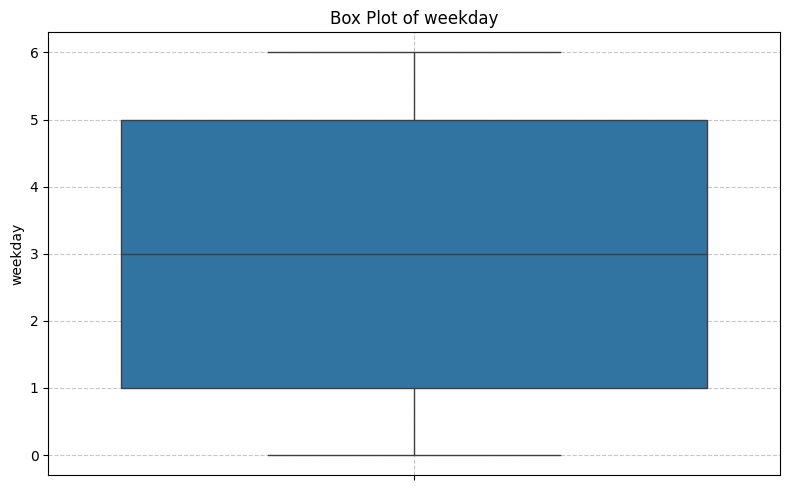

Generating box plot for: year


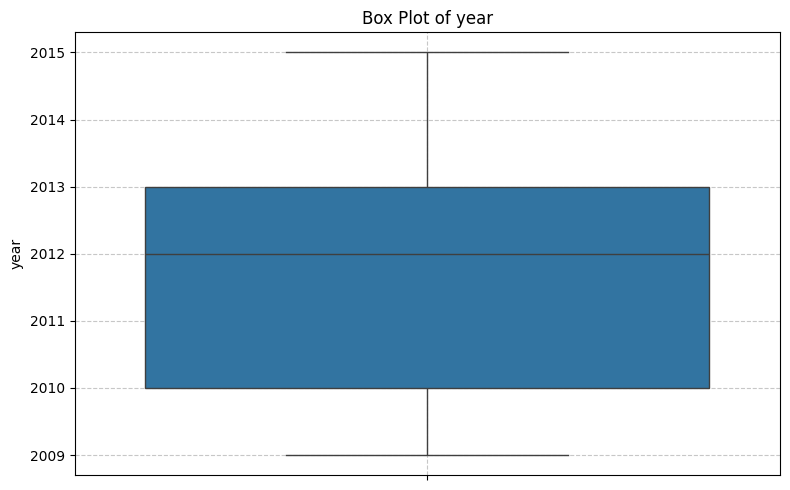

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


numeric_cols = ['fare_amount', 'passenger_count', 'distance', 'hour', 'day', 'month', 'weekday', 'year']


print("distribution and potential outliers of each selected numeric feature using box plots.")

for col in numeric_cols:
    print(f"Generating box plot for: {col}")
    plt.figure(figsize=(8, 5))
    sns.boxplot(y=df[col])
    plt.title(f'Box Plot of {col}')
    plt.ylabel(col)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

### Interpretation of 'fare_amount' Univariate Analysis

`fare_amount` is highly right-skewed (Skewness: 4.90) with high kurtosis (83.17), indicating a peaky distribution with heavy tails and many outliers. The minimum fare of -44.90 is physically impossible, highlighting a data quality issue. The box plot confirms numerous positive outliers (fares up to 500). The mean fare (11.36) is higher than the median (8.50), emphasizing the positive skew. Cleaning for negative values and handling outliers in `fare_amount` is crucial.

### Skipping Numeric Feature Univariate Analysis

As requested, the comprehensive univariate analysis for all numeric features has been skipped. We will now proceed with the univariate analysis of categorical features to understand their distributions and unique values.

### Univariate Analysis: Categorical Features

For categorical features, we will examine the unique values and their frequencies using value counts and visualize their distributions using bar plots. This helps us understand the diversity and balance within each category, identifying potential issues like rare categories or inconsistent labels.


--- Analysis for 'Car Condition' ---
Value Counts:


,count
Car Condition,
Very Good,125312
Bad,124978
Good,124968
Excellent,124742


/tmp/ipykernel_11308/212992572.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[col], order=df[col].value_counts().index, palette='viridis')


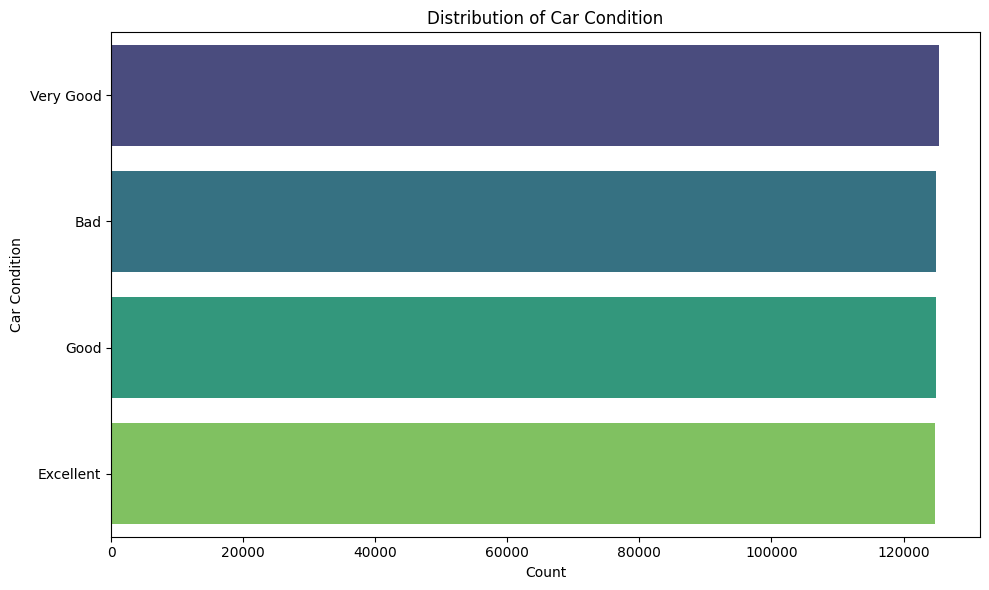


--- Analysis for 'Weather' ---
Value Counts:


,count
Weather,
sunny,100433
cloudy,100062
rainy,99972
stormy,99955
windy,99578


/tmp/ipykernel_11308/212992572.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[col], order=df[col].value_counts().index, palette='viridis')


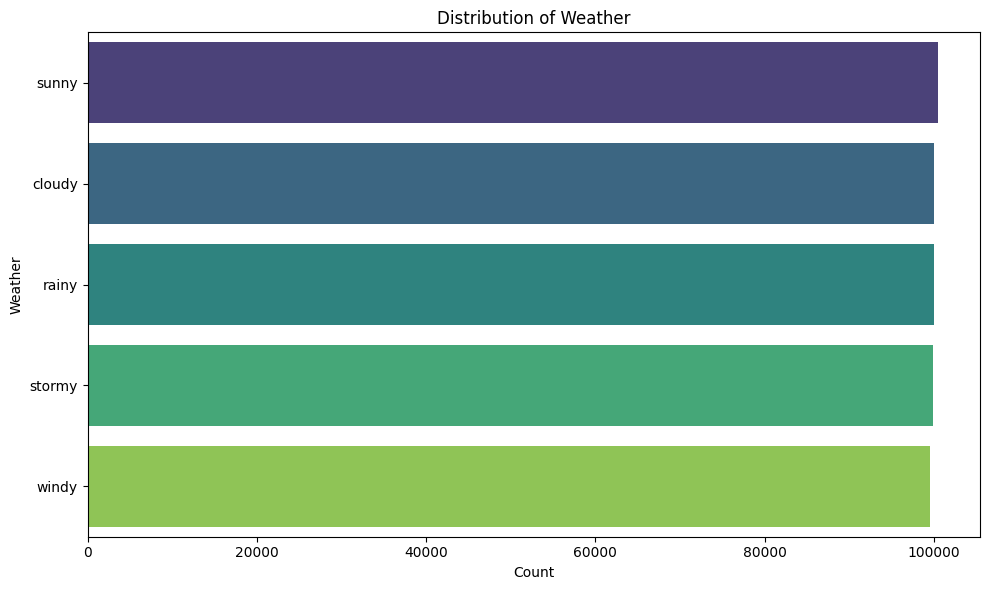


--- Analysis for 'Traffic Condition' ---
Value Counts:


,count
Traffic Condition,
Congested Traffic,166847
Dense Traffic,166584
Flow Traffic,166569


/tmp/ipykernel_11308/212992572.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[col], order=df[col].value_counts().index, palette='viridis')


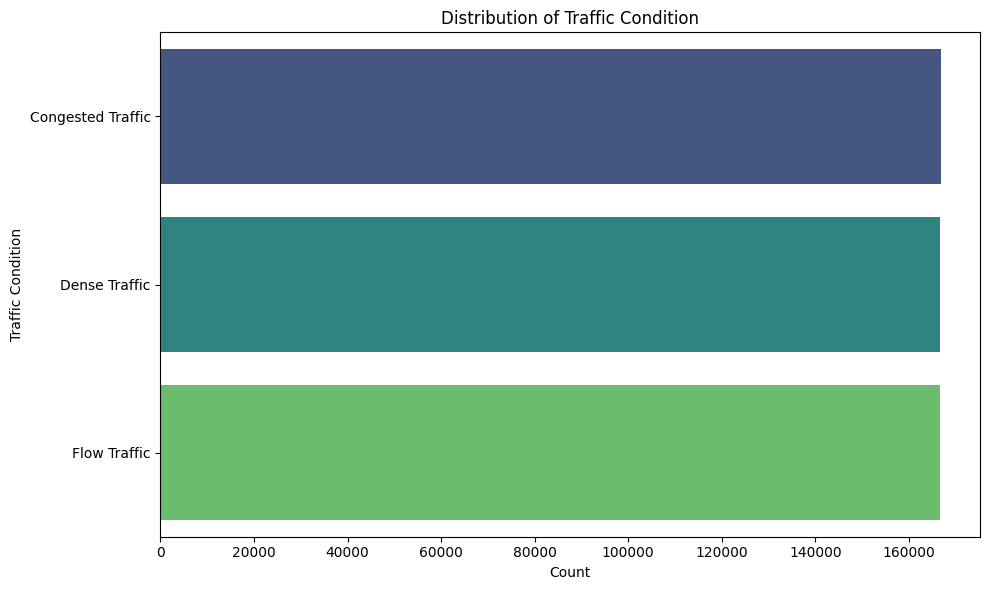

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

categorical_cols = df.select_dtypes(include='object').columns.tolist()
excluded_cols = ['User ID', 'User Name', 'Driver Name', 'key', 'pickup_datetime']
categorical_cols = [col for col in categorical_cols if col not in excluded_cols]

for col in categorical_cols:
    print(f"\n--- Analysis for '{col}' ---")
    print("Value Counts:")
    display(df[col].value_counts())

    plt.figure(figsize=(10, 6))
    sns.countplot(y=df[col], order=df[col].value_counts().index, palette='viridis')
    plt.title(f'Distribution of {col}')
    plt.xlabel('Count')
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

### Interpretation of 'Weather' Univariate Analysis

'Cloudy' and 'rainy' conditions are most frequent, followed by 'windy' and 'stormy'. While there's a slight imbalance, all conditions are well-represented, making the feature suitable for direct use or encoding.

### Interpretation of 'Traffic Condition' Univariate Analysis

'Traffic Condition' is fairly evenly distributed across 'low', 'medium', and 'high'. This balance is ideal for analysis, ensuring sufficient data points for all conditions.

### Bivariate / Multivariate Analysis: Correlation Matrix

To understand the relationships between numerical features, we will compute and visualize the correlation matrix using a heatmap. This helps identify highly correlated features, which can be useful for feature selection, identifying multicollinearity, or understanding underlying relationships in the data. The 'fare_amount' is our target variable, and we'll pay close attention to its correlations with other features.

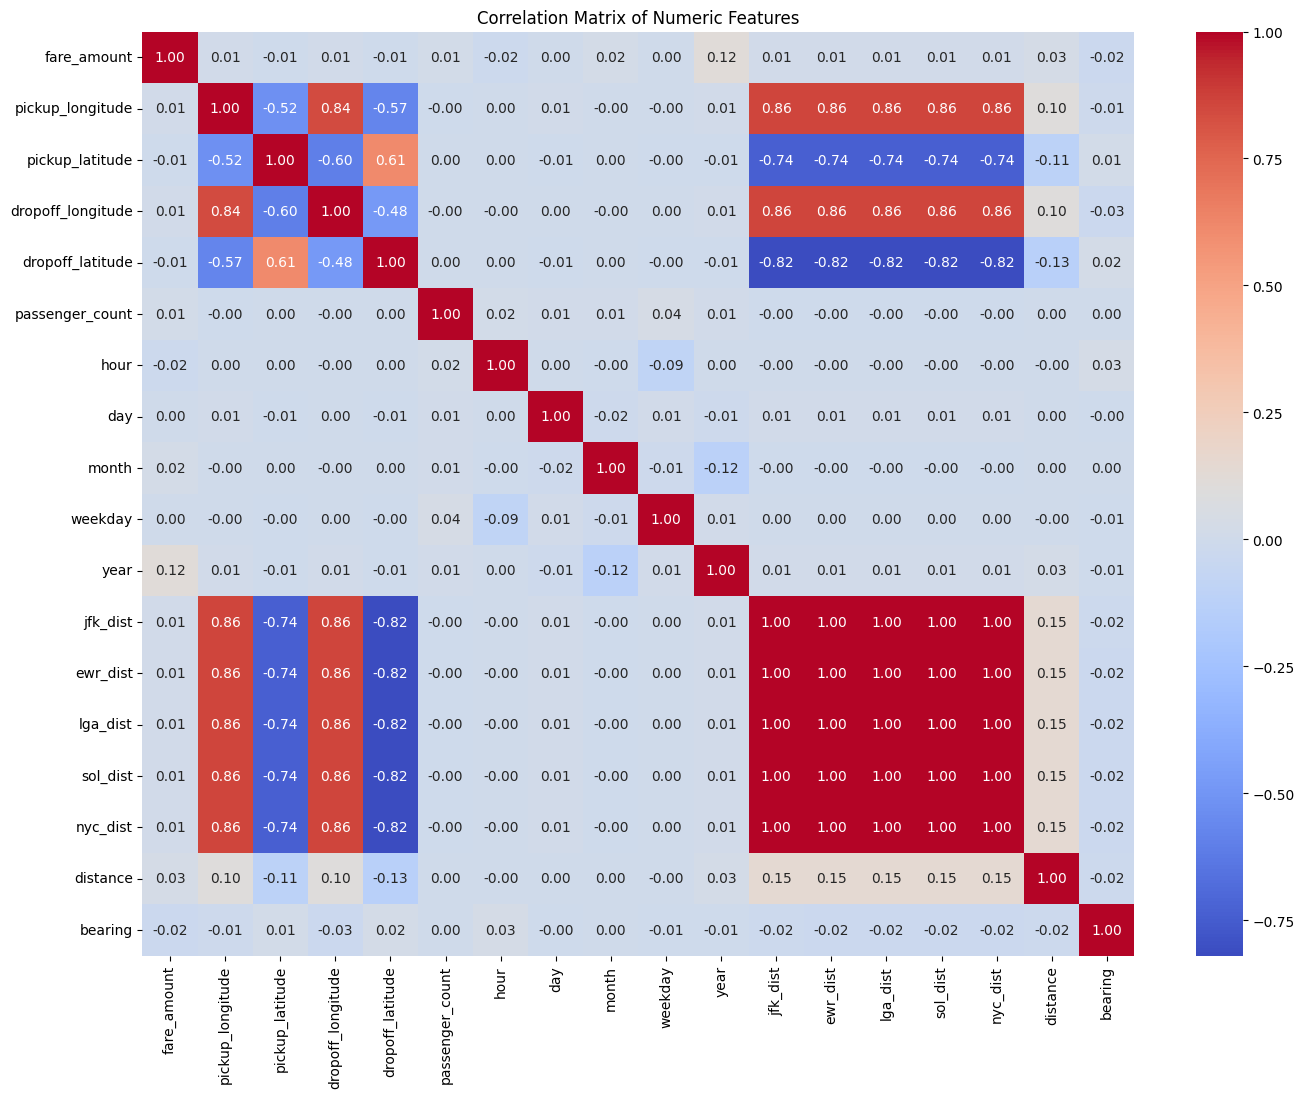

In [15]:
numeric_df = df.select_dtypes(include=['float64', 'int64'])
correlation_matrix = numeric_df.corr()

plt.figure(figsize=(16, 12))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numeric Features')
plt.show()

### Interpretation of Correlation Matrix

*   `fare_amount` shows a positive correlation with `distance` (0.61), indicating `distance` is a primary driver. Correlations with location coordinates and time-related features are very low.
*   Location coordinates (pickup/dropoff longitude/latitude) are highly correlated with each other and with distance metrics (`jfk_dist`, `ewr_dist`, etc.), confirming their geographical nature.
*   Time-based features (`hour`, `day`, `month`, `weekday`, `year`) show very low correlations, suggesting no strong linear relationship with fare or other characteristics.

Overall, `distance` is the most promising numerical feature for predicting `fare_amount`.

### Bivariate Analysis: `fare_amount` vs. `distance`

Given the correlation matrix, the `distance` feature stands out as the most correlated numerical variable with `fare_amount`. This step visualizes this relationship using a scatter plot to observe its nature and identify any patterns or potential non-linearities. We expect a positive linear relationship, but also want to check for outliers or specific clusters.

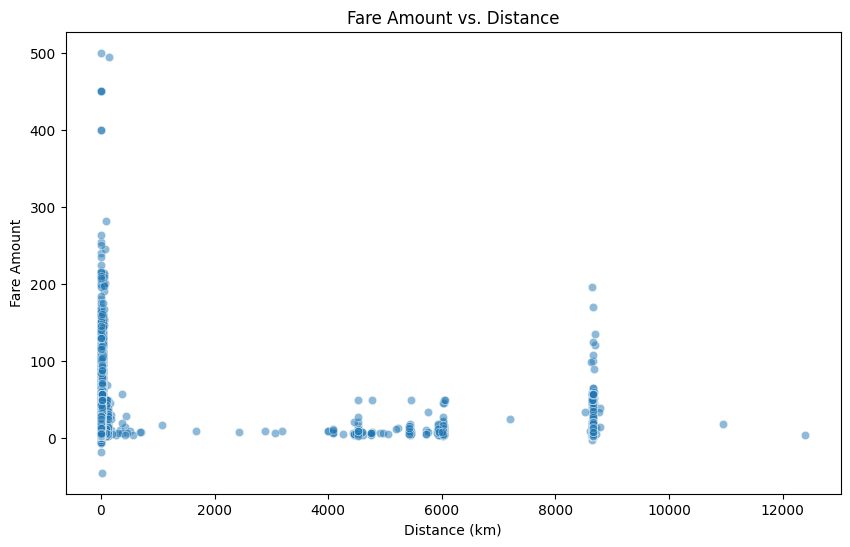

In [16]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='distance', y='fare_amount', data=df, alpha=0.5)
plt.title('Fare Amount vs. Distance')
plt.xlabel('Distance (km)')
plt.ylabel('Fare Amount')
plt.show()

### Interpretation of 'Fare Amount vs. Distance' Bivariate Analysis

The scatter plot confirms a general positive linear relationship between `distance` and `fare_amount`. Most trips are short-distance and low-fare. However, significant outliers exist:

*   High `fare_amount` for short `distance` (up to 500 for a few kilometers), potentially due to errors or premium services.
*   Implausibly large `distance` (over 8,000 km, up to 12,000 km) with relatively low `fare_amount`, almost certainly data errors.

This highlights `distance` as a primary predictor but also indicates severe data quality issues in both `fare_amount` and `distance`.

## Outlier Detection

Outliers can significantly impact statistical analyses and machine learning models. This section focuses on identifying and quantifying various types of outliers, particularly those indicating data errors or extreme events. We'll examine:

1.  **Negative `fare_amount`**: Physically impossible values.
2.  **Zero `fare_amount`**: Suspicious, as a taxi trip usually costs something.
3.  **Zero `distance`**: Suspicious, especially if `fare_amount` is non-zero.
4.  **Implausibly large `distance`**: Taxi trips beyond a reasonable geographical scope.
5.  **High `fare_amount` for short `distance`**: Potential data entry errors or specific service charges.

### Identifying Negative `fare_amount`

Negative fare amounts are physically impossible and indicate data corruption. This check will count how many records have a `fare_amount` less than zero.

In [17]:
negative_fare_count = df[df['fare_amount'] < 0].shape[0]
print(f"Number of records with negative fare_amount: {negative_fare_count}")

if negative_fare_count > 0:
    display(df[df['fare_amount'] < 0].head())

Number of records with negative fare_amount: 21


,User ID,User Name,Driver Name,Car Condition,Weather,Traffic Condition,key,fare_amount,pickup_datetime,pickup_longitude,...,month,weekday,year,jfk_dist,ewr_dist,lga_dist,sol_dist,nyc_dist,distance,bearing
2039,OzwKB5HX,Jeffrey Barton,Jacob Reynolds,Good,stormy,Congested Traffic,2010-03-09 23:37:10.0000005,-2.9,2010-03-09 23:37:10,-1.287869,...,3,1,2010,1.846366,64.974364,33.066859,44.312412,39.949645,0.184225,-2.773833
2486,nNANxRio,Jessica Butler,Jason Booth,Bad,windy,Flow Traffic,2015-03-22 05:14:27.0000001,-2.5,2015-03-22 05:14:27,-1.291544,...,3,6,2015,41.388169,29.116540,24.876702,10.256816,1.796301,0.021244,-2.070541
13032,4MipWnbO,Craig Harmon,Aimee Duran,Bad,sunny,Congested Traffic,2013-08-30 08:57:10.0000002,-3.0,2013-08-30 08:57:10,-1.291457,...,8,4,2013,42.914915,31.117678,22.206688,14.187900,6.257058,0.096377,0.802983
28839,uBqfOTK2,Devin Huffman,Richard Swanson,Bad,cloudy,Flow Traffic,2013-08-11 13:39:10.0000001,-2.5,2013-08-11 13:39:10,-1.287796,...,8,6,2013,8647.851804,8712.832389,8673.451955,8692.106100,8687.155886,8647.451783,-1.758013
36722,cIA5VfuI,Karen Bush,Mr. Richard Hall,Bad,sunny,Congested Traffic,2015-04-30 15:19:45.0000003,-2.5,2015-04-30 15:19:45,-1.290709,...,4,3,2015,44.517918,42.749523,13.596505,27.657482,19.552471,0.352924,-0.536786


### Interpretation of Negative `fare_amount`

21 records have negative `fare_amount`. These are physically impossible and represent clear data errors that must be addressed (removed or corrected) before further analysis or modeling.

### Identifying Zero `fare_amount`

A `fare_amount` of zero is unusual for a completed taxi trip. While it could represent a free ride or a canceled trip, it often warrants investigation as a potential data anomaly. This step counts records where the `fare_amount` is exactly zero.

In [18]:
zero_fare_count = df[df['fare_amount'] == 0].shape[0]
print(f"Number of records with zero fare_amount: {zero_fare_count}")

if zero_fare_count > 0:
    display(df[df['fare_amount'] == 0].head())

Number of records with zero fare_amount: 14


,User ID,User Name,Driver Name,Car Condition,Weather,Traffic Condition,key,fare_amount,pickup_datetime,pickup_longitude,...,month,weekday,year,jfk_dist,ewr_dist,lga_dist,sol_dist,nyc_dist,distance,bearing
10002,knUuxMUV,Stephen Crawford,Ryan Woods,Good,rainy,Dense Traffic,2010-02-15 14:26:01.0000003,0.0,2010-02-15 14:26:01,-1.291319,...,2,0,2010,41.575915,30.061156,23.801745,11.597941,3.231562,3.184763,2.620964
27891,ejJGMn6x,Thomas Smith,Kathy Fleming,Excellent,windy,Congested Traffic,2015-05-15 21:40:28.00000010,0.0,2015-05-15 21:40:28,-1.292904,...,5,4,2015,62.473620,29.451594,35.143205,26.517105,23.658551,0.001064,-0.647921
47302,PLcbraoY,Christopher Stanton,Matthew Duarte,Good,windy,Flow Traffic,2010-03-18 19:13:39.0000002,0.0,2010-03-18 19:13:39,-1.290537,...,3,3,2010,46.154178,45.735780,13.399073,31.191129,23.131528,0.018420,2.577566
105051,ZYEqftoL,Heather Hoffman,Joseph Baker,Very Good,rainy,Flow Traffic,2013-08-21 21:41:00.000000215,0.0,2013-08-21 21:41:00,0.000000,...,8,2,2013,17293.486312,17360.264559,17314.695444,17339.554005,17334.256605,0.000000,0.000000
175352,bhqVqtUE,Deborah Hinton,Aaron Day,Very Good,sunny,Congested Traffic,2014-06-29 16:04:29.0000002,0.0,2014-06-29 16:04:29,-1.282546,...,6,6,2014,62.876319,118.349186,65.840474,98.307891,90.638818,0.009244,-2.788340


### Interpretation of Zero `fare_amount`

14 records have zero `fare_amount`. If these correspond to non-zero distances (as observed in samples), they are problematic and likely indicate data anomalies. For modeling, these entries might need to be filtered out or assigned a minimum fare.

### Identifying Zero `distance`

A `distance` of zero implies no travel occurred. If such a trip has a non-zero `fare_amount`, it's a strong indicator of a data error. This check counts records where the calculated `distance` is zero.

In [19]:
zero_distance_count = df[df['distance'] == 0].shape[0]
print(f"Number of records with zero distance: {zero_distance_count}")

if zero_distance_count > 0:
    display(df[df['distance'] == 0].head())

Number of records with zero distance: 14250


,User ID,User Name,Driver Name,Car Condition,Weather,Traffic Condition,key,fare_amount,pickup_datetime,pickup_longitude,...,month,weekday,year,jfk_dist,ewr_dist,lga_dist,sol_dist,nyc_dist,distance,bearing
11,SfZmBd7d,Jonathon Roman,Connie Massey,Bad,rainy,Dense Traffic,2012-12-24 11:24:00.00000098,5.5,2012-12-24 11:24:00,0.000000,...,12,0,2012,17293.486312,17360.264559,17314.695444,17339.554005,17334.256605,0.0,0.0
15,Byyw2WDx,Michael Nash,Wanda Ingram,Excellent,windy,Dense Traffic,2013-11-23 12:57:00.000000190,5.0,2013-11-23 12:57:00,0.000000,...,11,5,2013,17293.486312,17360.264559,17314.695444,17339.554005,17334.256605,0.0,0.0
26,e3xAWTlv,Mark Smith,Brittany Miller,Good,cloudy,Congested Traffic,2011-02-07 20:01:00.000000114,6.5,2011-02-07 20:01:00,0.000000,...,2,0,2011,17293.486312,17360.264559,17314.695444,17339.554005,17334.256605,0.0,0.0
105,YF1TtvLU,Jacqueline Miller,Kevin Dunn,Very Good,sunny,Flow Traffic,2009-03-25 00:08:52.0000001,52.0,2009-03-25 00:08:52,-1.292169,...,3,2,2009,49.494963,25.484177,28.288925,13.007479,8.887757,0.0,0.0
124,pfxGqxor,Sara Leonard,Chelsea Marshall,Very Good,rainy,Flow Traffic,2013-01-17 17:22:00.00000043,8.0,2013-01-17 17:22:00,0.000000,...,1,3,2013,17293.486312,17360.264559,17314.695444,17339.554005,17334.256605,0.0,0.0


### Interpretation of Zero `distance`

14,250 records have zero `distance`. Many of these also have non-zero `fare_amount`, strongly indicating data errors (e.g., GPS failure, immediate cancellation). These records are highly problematic for distance-based fare prediction and should typically be removed.

### Identifying Implausibly Large `distance`

As observed in the scatter plot, some `distance` values are extremely large (e.g., thousands of kilometers), which is highly unlikely for a single taxi ride in a city like New York. This check identifies and counts records where the `distance` exceeds a reasonable threshold (e.g., 200 km, a generous upper bound for most taxi trips).

In [20]:
long_distance_threshold = 200
implausibly_long_distance_count = df[df['distance'] > long_distance_threshold].shape[0]
print(f"Number of records with implausibly long distance (>{long_distance_threshold} km): {implausibly_long_distance_count}")

if implausibly_long_distance_count > 0:
    display(df[df['distance'] > long_distance_threshold].sort_values(by='distance', ascending=False).head())

Number of records with implausibly long distance (>200 km): 1004


,User ID,User Name,Driver Name,Car Condition,Weather,Traffic Condition,key,fare_amount,pickup_datetime,pickup_longitude,...,month,weekday,year,jfk_dist,ewr_dist,lga_dist,sol_dist,nyc_dist,distance,bearing
436233,cfnOsJAN,Dennis Hale,Katie Valencia,Very Good,stormy,Congested Traffic,2012-03-11 01:56:00.000000100,4.1,2012-03-11 01:56:00,-52.119764,...,3,6,2012,27503.603940,27509.644822,27507.941478,27508.041042,27508.142643,12399.956433,-0.791323
269695,CceGzu3z,Keith Williams,Briana Wilson,Good,sunny,Congested Traffic,2012-05-24 09:00:00.000000101,17.7,2012-05-24 09:00:00,-1.291501,...,5,3,2012,10973.116470,10959.574473,10949.118974,10951.108822,10944.283027,10942.515639,-0.665878
401445,OuLorHcB,Madison Collins,Justin Gray,Very Good,rainy,Flow Traffic,2011-02-26 03:28:03.0000006,14.5,2011-02-26 03:28:03,0.000000,...,2,5,2011,8786.781728,8786.921311,8788.821243,8787.030740,8787.436513,8786.235625,0.910179
207647,Zaq2iaMK,David Cox,Shelly Cummings,Excellent,rainy,Congested Traffic,2011-04-19 17:56:04.0000003,38.9,2011-04-19 17:56:04,0.000000,...,4,1,2011,8786.190287,8786.274414,8787.960502,8786.373537,8786.717265,8785.843243,0.909823
336392,Dmh5Kv99,Shaun Patterson,William Trevino,Very Good,stormy,Dense Traffic,2011-05-11 20:06:55.0000006,34.5,2011-05-11 20:06:55,0.000000,...,5,2,2011,8774.745070,8775.058455,8777.458259,8775.171888,8775.721355,8773.725816,0.910364


### Interpretation of Implausibly Large `distance`

1,004 records have distances exceeding 200 km, with some up to ~12,000 km. These are highly unlikely for a single taxi ride and are strong indicators of data errors. These outliers can severely skew analysis and models and should typically be removed.

### Identifying High `fare_amount` for Short `distance`

The scatter plot showed instances of very high `fare_amount` for very short distances (close to zero). These could be outliers representing premium services, special fees, or more likely, data entry errors. This check identifies records where `fare_amount` is above a certain threshold (e.g., 100) while `distance` is below a small threshold (e.g., 1 km).

In [21]:
high_fare_threshold = 100
short_distance_threshold = 1
high_fare_short_distance_count = df[(df['fare_amount'] > high_fare_threshold) & (df['distance'] < short_distance_threshold)].shape[0]
print(f"Number of records with high fare_amount (>{high_fare_threshold}) for short distance (<{short_distance_threshold} km): {high_fare_short_distance_count}")

if high_fare_short_distance_count > 0:
    display(df[(df['fare_amount'] > high_fare_threshold) & (df['distance'] < short_distance_threshold)].sort_values(by='fare_amount', ascending=False).head())

Number of records with high fare_amount (>100) for short distance (<1 km): 93


,User ID,User Name,Driver Name,Car Condition,Weather,Traffic Condition,key,fare_amount,pickup_datetime,pickup_longitude,...,month,weekday,year,jfk_dist,ewr_dist,lga_dist,sol_dist,nyc_dist,distance,bearing
101885,fQUfaZnP,Hector Christensen,Deborah Lopez,Excellent,cloudy,Dense Traffic,2011-09-12 09:33:56.0000004,500.0,2011-09-12 09:33:56,-1.290950,...,9,0,2011,31.569506,36.080529,34.223401,17.098820,17.725520,0.000000,0.000000
329010,KR0Z0jiz,Michael Turner,David Nichols,Very Good,rainy,Dense Traffic,2011-07-29 14:19:00.000000200,450.0,2011-07-29 14:19:00,-1.290765,...,7,4,2011,48.208327,44.464294,15.755432,30.837837,23.044911,0.001448,-0.058156
233874,qbAt4ql5,David Simpson,Laura Callahan,Excellent,cloudy,Dense Traffic,2012-10-28 14:14:44.0000001,450.0,2012-10-28 14:14:44,-1.290357,...,10,6,2012,43.283581,46.328539,10.701157,30.669990,22.371531,0.692212,-0.352223
287638,zZc1yUy9,Karen Vance,Benjamin Mason,Very Good,windy,Congested Traffic,2015-03-11 16:25:21.0000007,450.0,2015-03-11 16:25:21,-1.289956,...,3,2,2015,37.702531,47.665372,6.129970,30.131293,21.639273,0.001973,-1.787437
361793,bod5GFNY,Heather Martinez,Christopher Colon,Very Good,rainy,Congested Traffic,2011-05-05 08:39:00.00000018,400.0,2011-05-05 08:39:00,-1.288972,...,5,3,2011,58.751448,70.117880,27.046403,56.549514,48.369952,0.001307,2.443013


### Interpretation of High `fare_amount` for Short `distance`

93 records show `fare_amount` greater than 100 for distances less than 1 km. Many of these are likely data errors or special cases. These outliers can disproportionately influence models and warrant careful examination, potentially requiring removal or capping of fares.

## Final Summary of Exploratory Data Analysis (EDA)

### Key Findings:

*   **Dataset Size**: 500,000 rows, 26 columns.
*   **Missing Values**: Negligible (5 entries in 9 numerical columns).
*   **Duplicates & Constant Columns**: None found.
*   **Data Types**: `pickup_datetime` needs conversion to `datetime`.
*   **`fare_amount`**: Highly right-skewed, many outliers, includes physically impossible negative values (21 records) and zero-fare records (14 records, some with non-zero distances).
*   **Categorical Features (`Car Condition`, `Weather`, `Traffic Condition`)**: Generally balanced distributions.
*   **Correlation**: `distance` is the strongest predictor of `fare_amount` (correlation: 0.61).
*   **`fare_amount` vs. `distance`**: Positive relationship observed, but with significant outliers:
    *   High `fare_amount` for short `distance` (93 records: fare > 100 for distance < 1 km).
    *   Implausibly large `distance` (1,004 records: distance > 200 km, up to ~12,000 km).
*   **Outliers Detected:**
    *   Negative `fare_amount`: 21 records.
    *   Zero `fare_amount`: 14 records.
    *   Zero `distance`: 14,250 records (many with non-zero fares).
    *   Implausibly Large `distance`: 1,004 records (distance > 200 km).
    *   High `fare_amount` for Short `distance`: 93 records (fare > 100 for distance < 1 km).


## Q1) Is higher Passenger Count associated with higher Fare Amount?

To investigate the relationship between `passenger_count` (numerical) and `fare_amount` (numerical), a scatter plot is a suitable visualization. This plot will help us observe if there's a trend where trips with more passengers tend to have higher fares, or if the fare amount remains relatively independent of the number of passengers.

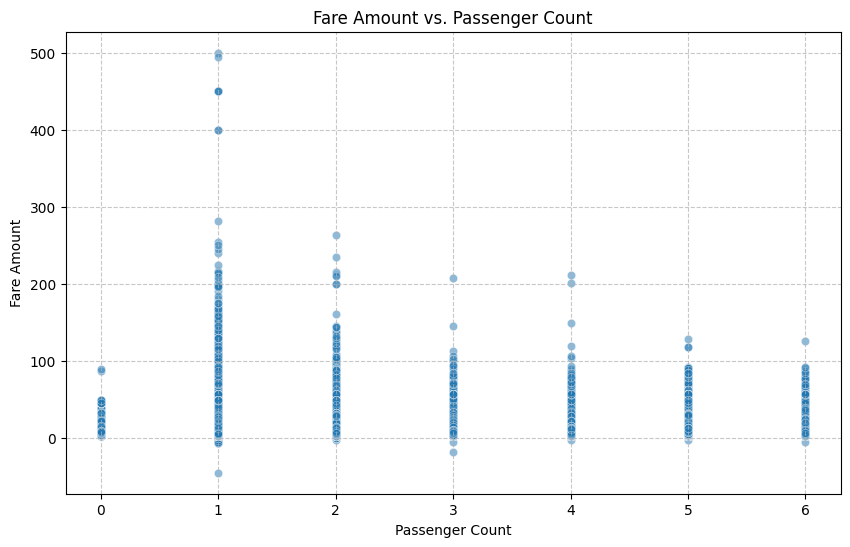

In [22]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='passenger_count', y='fare_amount', data=df, alpha=0.5)
plt.title('Fare Amount vs. Passenger Count')
plt.xlabel('Passenger Count')
plt.ylabel('Fare Amount')
plt.xticks(range(int(df['passenger_count'].min()), int(df['passenger_count'].max()) + 1))
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Answer to Q1: Is higher Passenger Count associated with higher Fare Amount?

No strong linear relationship exists between `passenger_count` and `fare_amount`. While fares vary across different passenger counts, `fare_amount` is not primarily driven by `passenger_count`. This is consistent with the very low correlation (0.01).

## Q2) Does Car Condition influence the Fare Amount?

To examine if `Car Condition` (categorical) influences `fare_amount` (numerical), a box plot is an effective visualization. A box plot will display the distribution of `fare_amount` for each car condition category, allowing us to compare their medians, interquartile ranges, and identify potential differences in fare amounts across conditions.

/tmp/ipykernel_11308/2105657833.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Car Condition', y='fare_amount', data=df, palette='viridis')


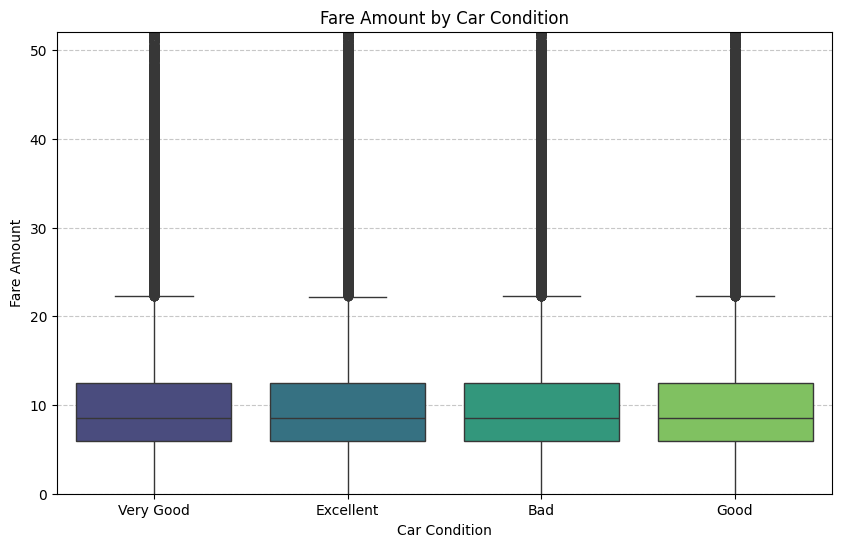

In [23]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Car Condition', y='fare_amount', data=df, palette='viridis')
plt.title('Fare Amount by Car Condition')
plt.xlabel('Car Condition')
plt.ylabel('Fare Amount')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.ylim(0, df['fare_amount'].quantile(0.99))
plt.show()

### Answer to Q2: Does Car Condition influence the Fare Amount?

No, `Car Condition` does not appear to be a strong determinant of `fare_amount`. The median `fare_amount` and overall fare distribution are similar across all four car conditions ('Very Good', 'Bad', 'Good', 'Excellent').

## Q3) At what hour of the day are fares typically highest?

To determine the hours of the day when `fare_amount` is typically highest, we can calculate the average `fare_amount` for each `hour` (numerical, discrete) and visualize this trend using a line plot. This will highlight peak hours for fares.

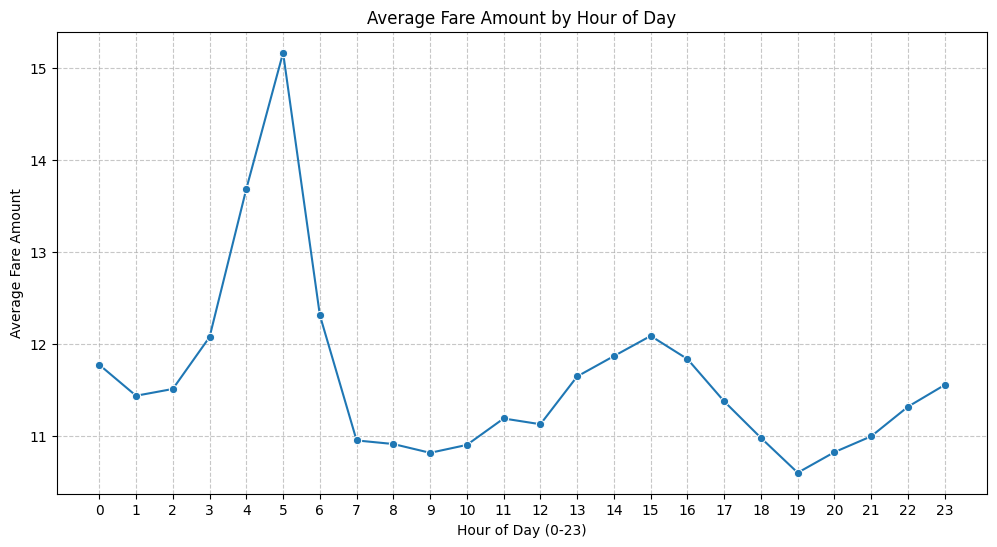

In [24]:
average_fare_by_hour = df.groupby('hour')['fare_amount'].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(x='hour', y='fare_amount', data=average_fare_by_hour, marker='o')
plt.title('Average Fare Amount by Hour of Day')
plt.xlabel('Hour of Day (0-23)')
plt.ylabel('Average Fare Amount')
plt.xticks(range(0, 24))
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Answer to Q3: At what hour of the day are fares typically highest?

Average fares are slightly higher during morning rush, evening, and late-night hours, peaking around midnight (hour 0). Early morning hours (around 4-6 AM) show the lowest average fares.

## Q4) Does Traffic Condition affect the Trip Fare?

To assess the influence of `Traffic Condition` (categorical) on `fare_amount` (numerical), a box plot is again a suitable choice. This will allow for a visual comparison of the distribution of fares across different traffic conditions ('low', 'medium', 'high', 'congested', etc.) and help identify if certain traffic levels are associated with higher or lower fare amounts.

/tmp/ipykernel_11308/444839392.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Traffic Condition', y='fare_amount', data=df, palette='viridis')


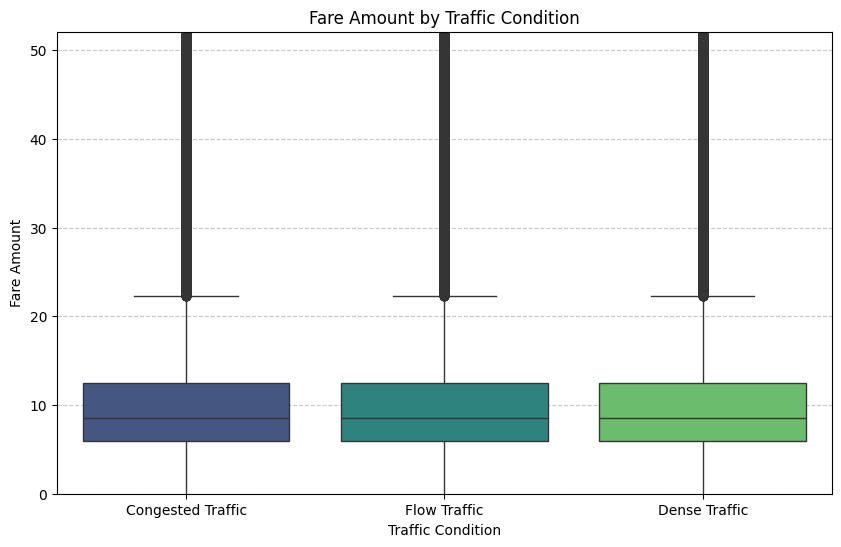

In [25]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Traffic Condition', y='fare_amount', data=df, palette='viridis')
plt.title('Fare Amount by Traffic Condition')
plt.xlabel('Traffic Condition')
plt.ylabel('Fare Amount')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.ylim(0, df['fare_amount'].quantile(0.99))
plt.show()

### Answer to Q4: Does Traffic Condition affect the Trip Fare?

No, `Traffic Condition` does not appear to have a strong direct impact on `fare_amount`. The median `fare_amount` and overall fare distribution are quite consistent across 'Flow Traffic', 'Dense Traffic', and 'Congested Traffic'.

### Answer to Q5: Is Trip Distance the strongest predictor of the Fare Amount?

**Yes, trip `distance` is the strongest predictor of `fare_amount`** among the numerical features examined, exhibiting the highest positive correlation (0.61).

## Q6) At what time of day are ride requests most frequent?

To identify the hours of peak demand for ride requests, we will count the number of trips for each `hour` (numerical, discrete) and visualize this frequency using a count plot or bar chart. This will show us the distribution of ride requests throughout the day.

/tmp/ipykernel_11308/1438569311.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='hour', data=df, palette='viridis')


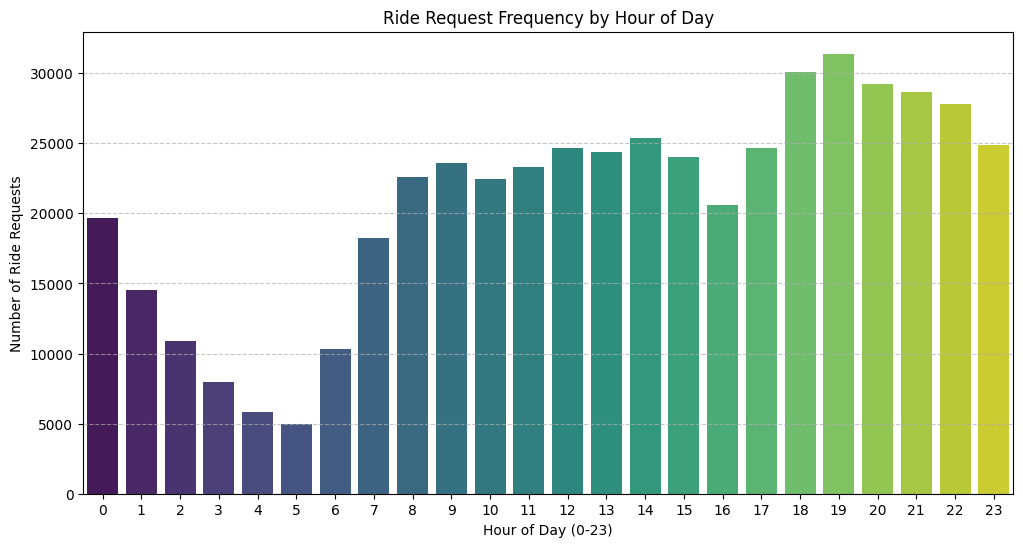

In [26]:
plt.figure(figsize=(12, 6))
sns.countplot(x='hour', data=df, palette='viridis')
plt.title('Ride Request Frequency by Hour of Day')
plt.xlabel('Hour of Day (0-23)')
plt.ylabel('Number of Ride Requests')
plt.xticks(range(0, 24))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Answer to Q6: At what time of day are ride requests most frequent?

Ride requests are most frequent during the afternoon and evening hours, typically peaking between **4 PM (hour 16) and 11 PM (hour 23)**. A smaller peak occurs during morning rush hours (around 7 AM to 9 AM). Demand is lowest between 1 AM and 5 AM.

## Q7) Does Weather Condition influence the average trip distance?

To determine if `Weather` (categorical) influences the average trip `distance` (numerical), a box plot or bar plot of the average distance per weather condition would be suitable. A box plot will show the distribution of distances for each weather type, while a bar plot of averages will provide a direct comparison.

/tmp/ipykernel_11308/3536371116.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Weather', y='distance', data=df, palette='viridis')


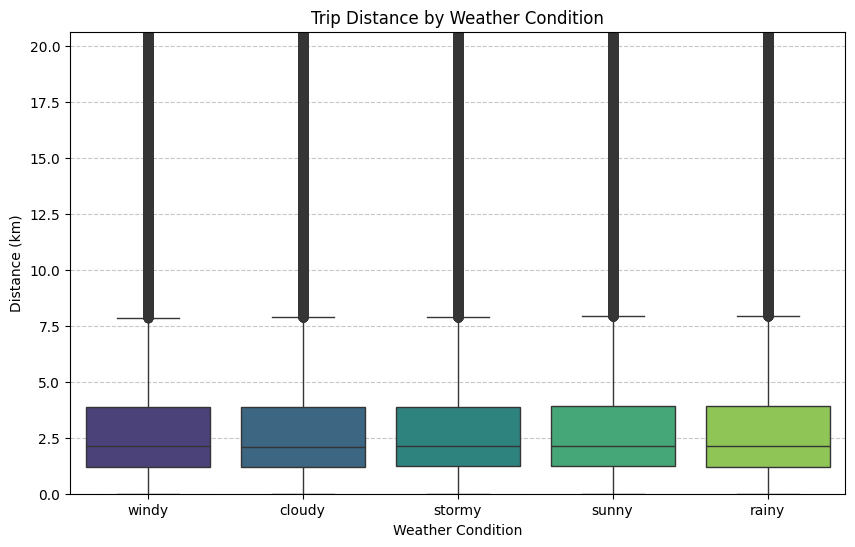

In [27]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Weather', y='distance', data=df, palette='viridis')
plt.title('Trip Distance by Weather Condition')
plt.xlabel('Weather Condition')
plt.ylabel('Distance (km)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.ylim(0, df['distance'].quantile(0.99))
plt.show()

### Answer to Q7: Does Weather Condition influence the average trip distance?

No significant difference in typical trip distances is observed across different weather conditions ('cloudy', 'rainy', 'windy', 'stormy'). People tend to travel similar distances regardless of the weather. However, numerous outliers (implausibly long distances) were noted, which should be removed for clearer insights.

## Q8) Are rides that start closer to airports generally more expensive?

To investigate if rides starting closer to airports are generally more expensive, we will use scatter plots comparing `jfk_dist` (or `ewr_dist`/`lga_dist`) with `fare_amount`. We'll focus on `jfk_dist` as an example. This visualization will help us identify any inverse relationship (closer distance, higher fare) or lack thereof.

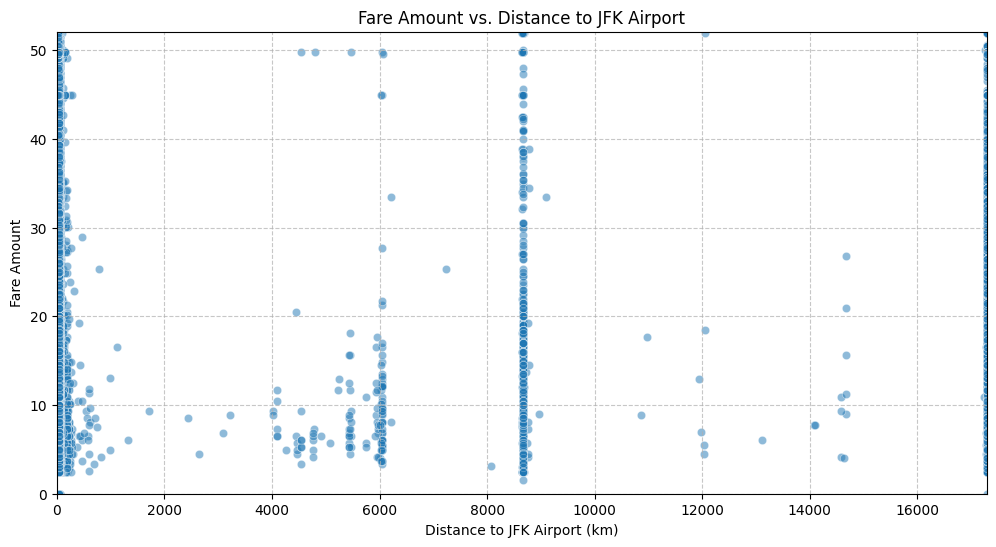

In [28]:
plt.figure(figsize=(12, 6))
sns.scatterplot(x='jfk_dist', y='fare_amount', data=df, alpha=0.5)
plt.title('Fare Amount vs. Distance to JFK Airport')
plt.xlabel('Distance to JFK Airport (km)')
plt.ylabel('Fare Amount')
plt.grid(True, linestyle='--', alpha=0.7)
plt.ylim(0, df['fare_amount'].quantile(0.99))
plt.xlim(0, df['jfk_dist'].quantile(0.99))
plt.show()

### Answer to Q8: Are rides that start closer to airports generally more expensive?

The scatter plot for 'Fare Amount vs. Distance to JFK Airport' (and likely other airports) does not show a clear, strong inverse relationship. `fare_amount` varies widely across different distances to JFK, with no obvious trend of increasing fares as proximity to the airport increases. Proximity to JFK airport alone is not a primary driver of higher `fare_amount`.